In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [2]:
df = pd.read_csv("heart1.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
pd.set_option("display.float", "{:.2f}".format)
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


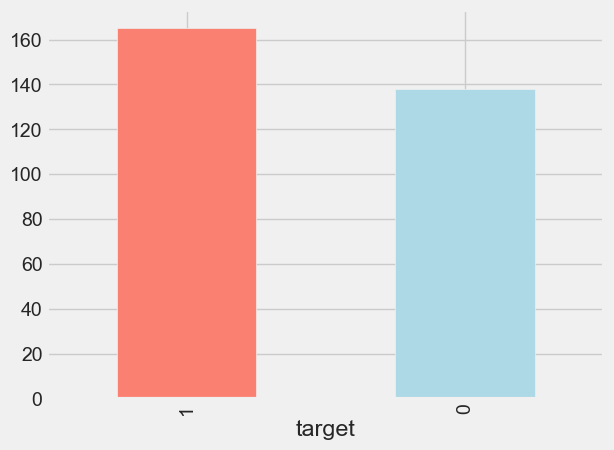

In [4]:
df.target.value_counts().plot(kind="bar",color=["salmon","lightblue"])
plt.show()

In [5]:
# Checking for messing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
categorical_val = []
continous_val = []
for column in df.columns:
    print('==============================')
    print(f"{column} : {df[column].unique()}")
    if len(df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

age : [63 37 41 56 57 44 52 54 48 49 64 58 50 66 43 69 59 42 61 40 71 51 65 53
 46 45 39 47 62 34 35 29 55 60 67 68 74 76 70 38 77]
sex : [1 0]
cp : [3 2 1 0]
trestbps : [145 130 120 140 172 150 110 135 160 105 125 142 155 104 138 128 108 134
 122 115 118 100 124  94 112 102 152 101 132 148 178 129 180 136 126 106
 156 170 146 117 200 165 174 192 144 123 154 114 164]
chol : [233 250 204 236 354 192 294 263 199 168 239 275 266 211 283 219 340 226
 247 234 243 302 212 175 417 197 198 177 273 213 304 232 269 360 308 245
 208 264 321 325 235 257 216 256 231 141 252 201 222 260 182 303 265 309
 186 203 183 220 209 258 227 261 221 205 240 318 298 564 277 214 248 255
 207 223 288 160 394 315 246 244 270 195 196 254 126 313 262 215 193 271
 268 267 210 295 306 178 242 180 228 149 278 253 342 157 286 229 284 224
 206 167 230 335 276 353 225 330 290 172 305 188 282 185 326 274 164 307
 249 341 407 217 174 281 289 322 299 300 293 184 409 259 200 327 237 218
 319 166 311 169 187 176 241 131]
fbs :

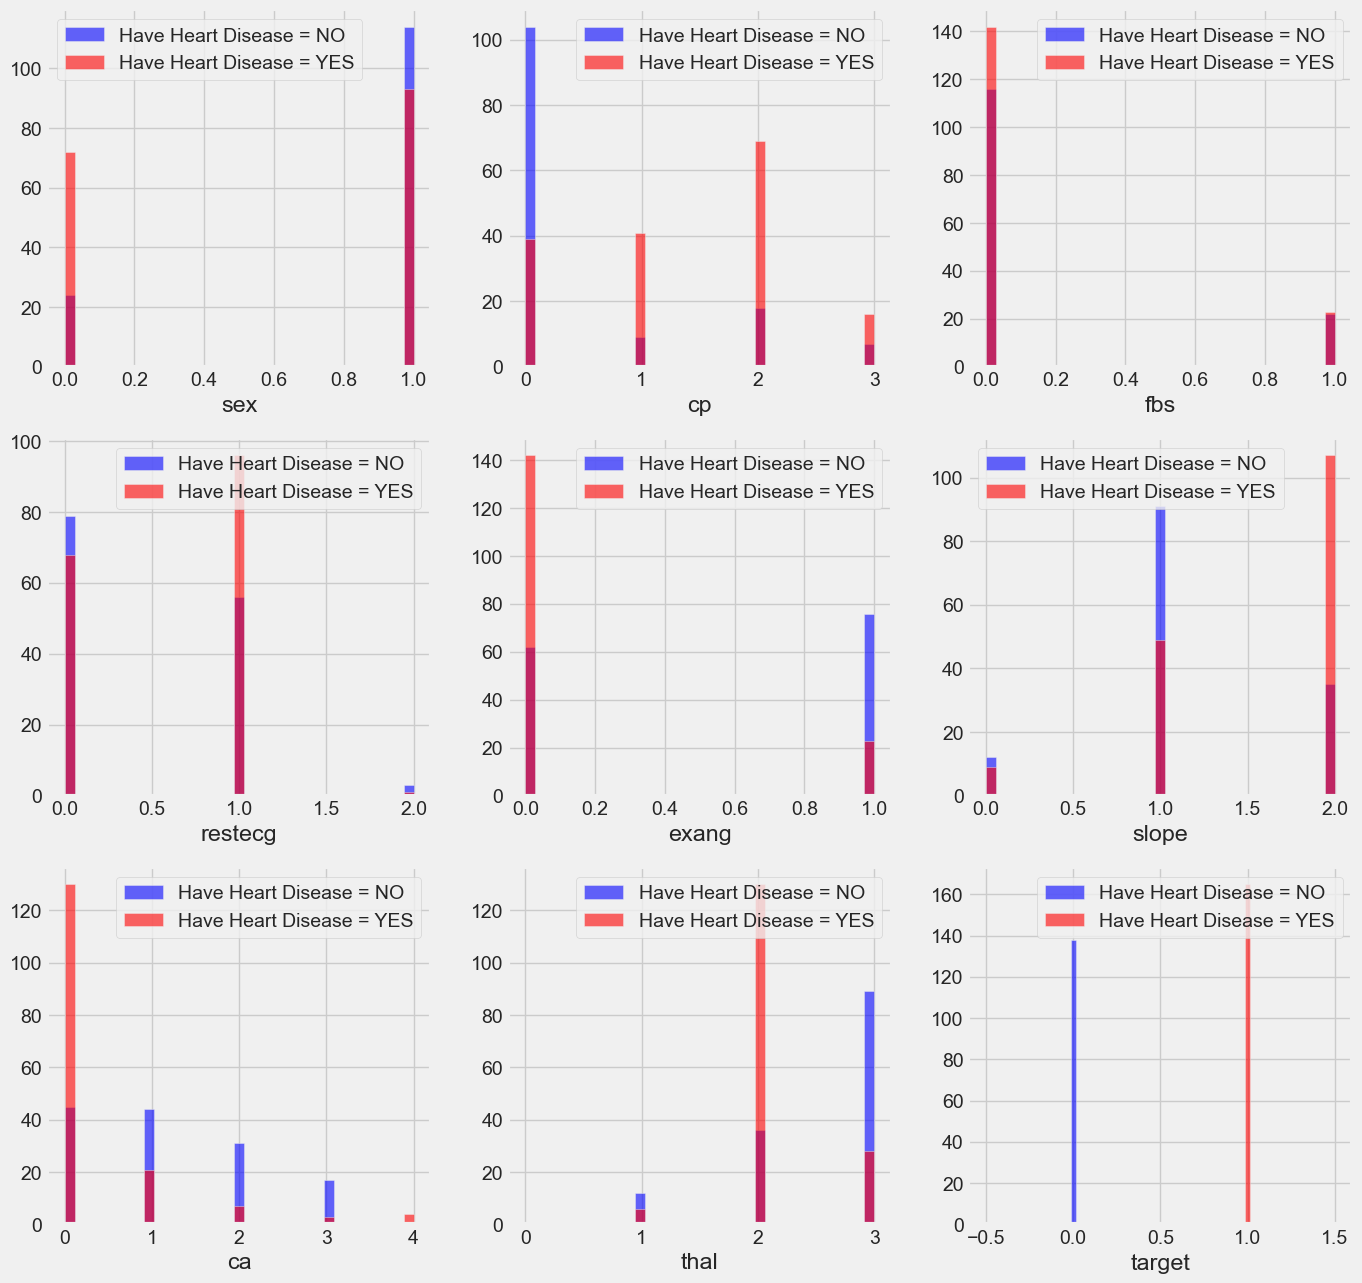

In [7]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(categorical_val, 1):
    plt.subplot(3, 3, i)
    df[df["target"] == 0][column].hist(bins=35, color='blue', label='Have Heart Disease = NO', alpha=0.6)
    df[df["target"] == 1][column].hist(bins=35, color='red', label='Have Heart Disease = YES', alpha=0.6)
    plt.legend()
    plt.xlabel(column)
plt.show()

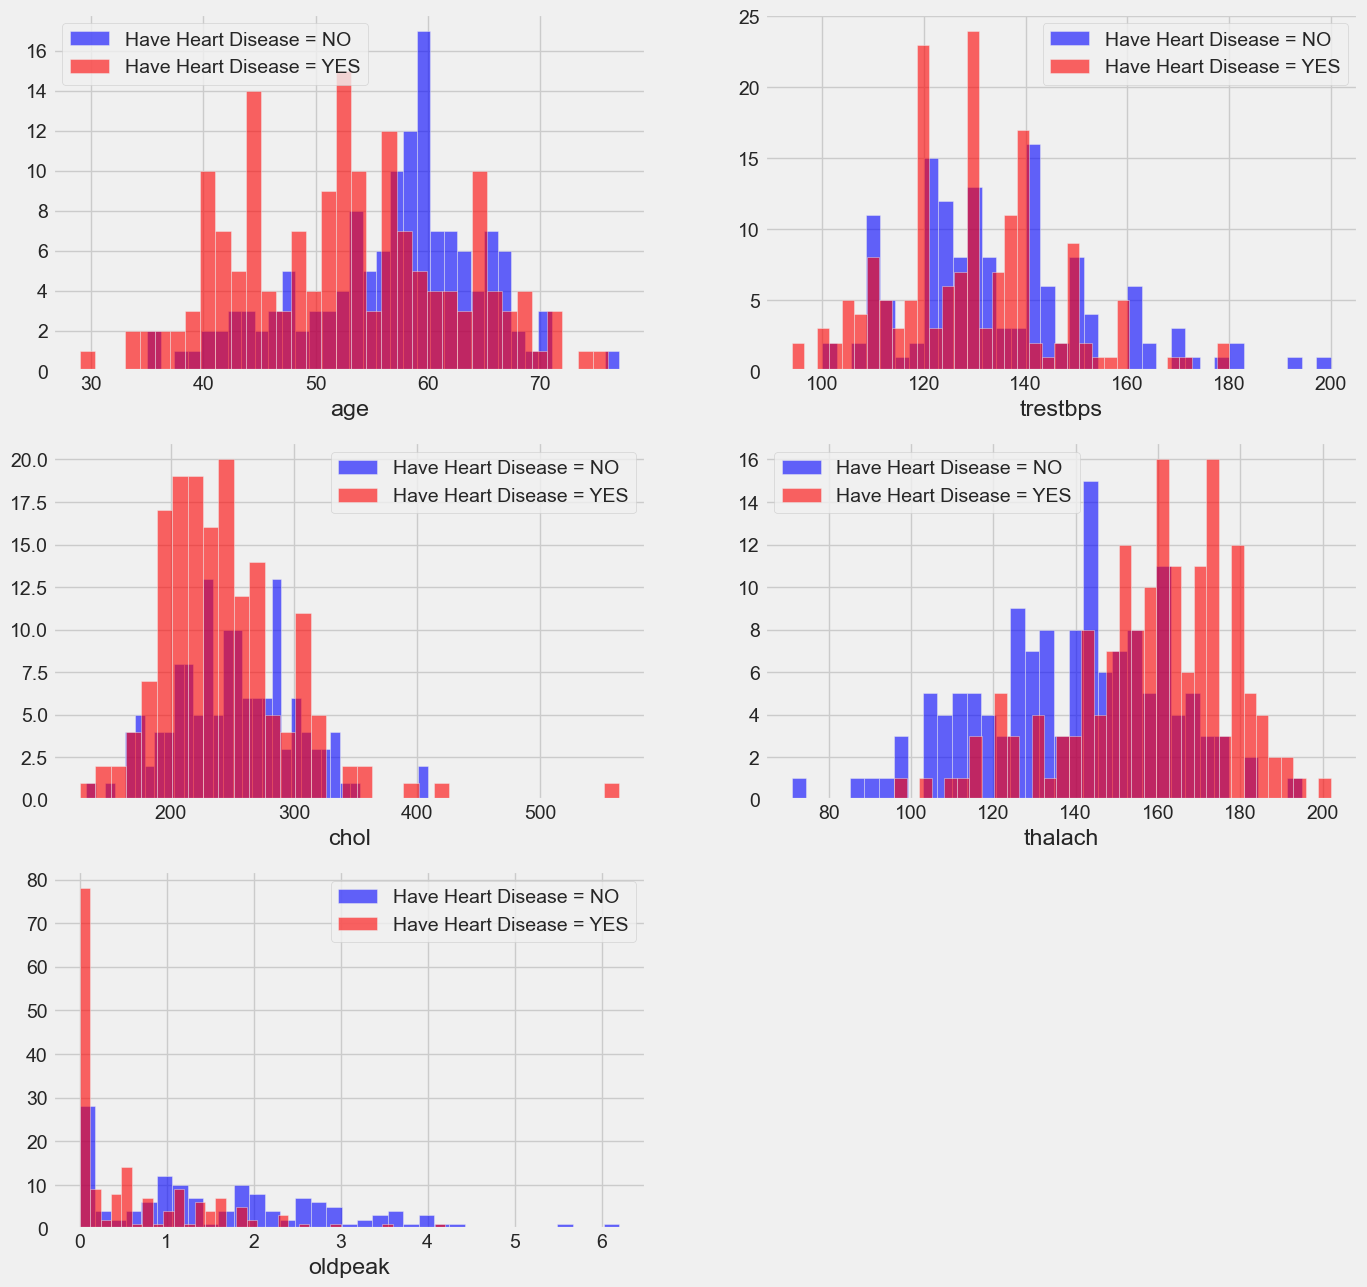

In [8]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(continous_val, 1):
    plt.subplot(3, 2, i)
    df[df["target"] == 0][column].hist(bins=35, color='blue', label='Have Heart Disease = NO', alpha=0.6)
    df[df["target"] == 1][column].hist(bins=35, color='red', label='Have Heart Disease = YES', alpha=0.6)
    plt.legend()
    plt.xlabel(column)
plt.show()

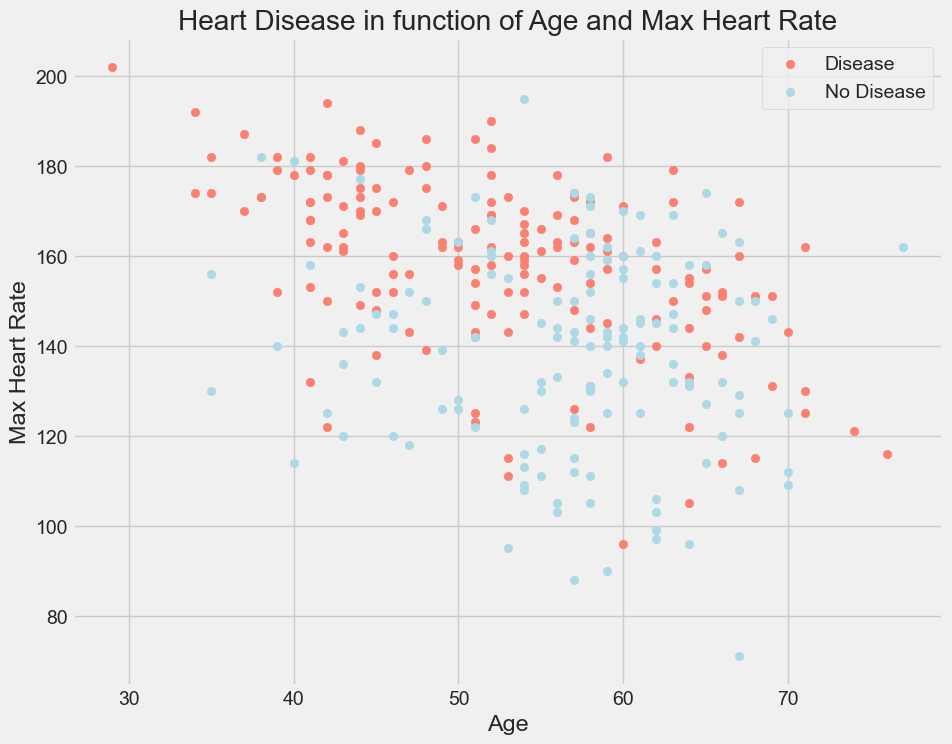

In [9]:
# Create another figure
plt.figure(figsize=(10, 8))

# Scatter with postivie examples
plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            c="salmon")

# Scatter with negative examples
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c="lightblue")

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);
plt.show()

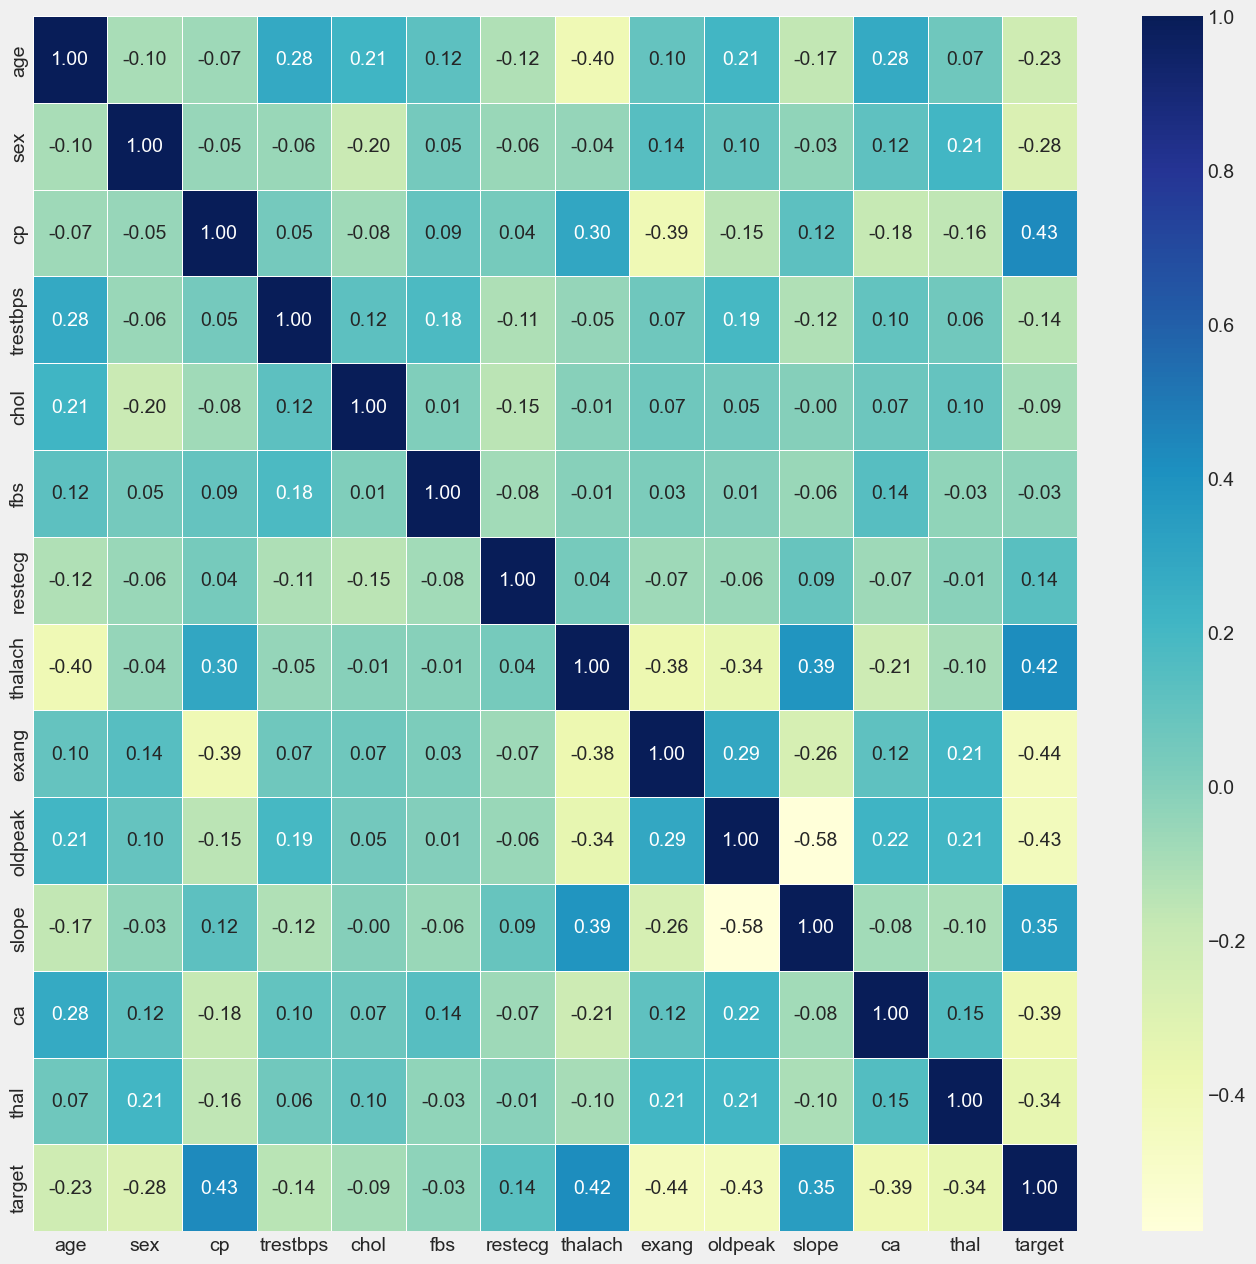

(14.5, -0.5)

In [10]:
# Let's make our correlation matrix a little prettier
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15, 15))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");
plt.show()
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

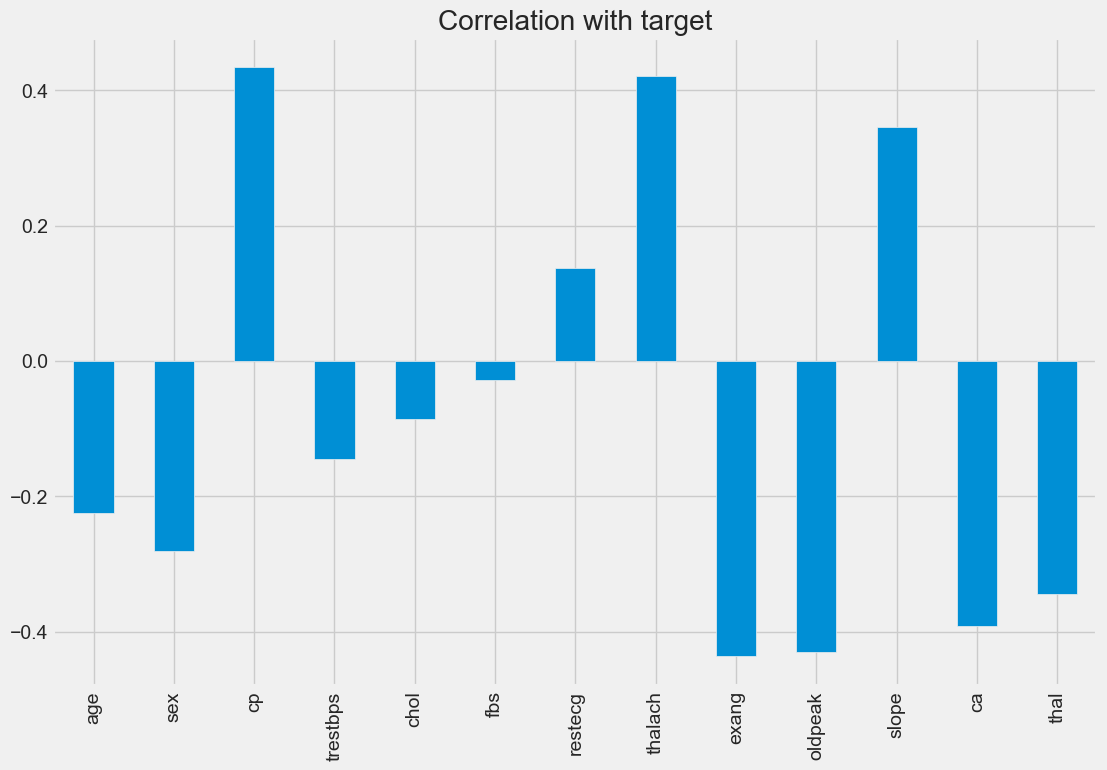

In [11]:
df.drop('target', axis=1).corrwith(df.target).plot(kind='bar', grid=True, figsize=(12, 8),title="Correlation with target")
plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler
import joblib

# Drop target from categorical columns
categorical_val = ['cp', 'restecg', 'slope', 'ca', 'thal']
categorical_val.remove('target') if 'target' in categorical_val else None

# One-hot encode categorical columns
dataset = pd.get_dummies(df, columns=categorical_val)

# Scale selected numerical columns
s_sc = StandardScaler()
col_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[col_to_scale] = s_sc.fit_transform(dataset[col_to_scale])

# Save the scaler
joblib.dump(s_sc, "scaler.pkl")

# Save the model columns after encoding
joblib.dump(dataset.drop('target', axis=1).columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def print_score(clf, X_train, y_train, X_test, y_test, train=True):
    if train:
        pred = clf.predict(X_train)
        clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
        print("Train Result:\n" + "="*48)
        print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
        print("Classification Report:\n", clf_report)
        print("Confusion Matrix:\n", confusion_matrix(y_train, pred), "\n")
    else:
        pred = clf.predict(X_test)
        clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))
        print("Test Result:\n" + "="*48)
        print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
        print("Classification Report:\n", clf_report)
        print("Confusion Matrix:\n", confusion_matrix(y_test, pred), "\n")


In [34]:
from sklearn.model_selection import train_test_split

X = dataset.drop("target", axis=1)
y = dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 212
Testing samples: 91


In [35]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(solver='liblinear', class_weight='balanced')
log_clf.fit(X_train, y_train)

print_score(log_clf, X_train, y_train, X_test, y_test, train=True)
print_score(log_clf, X_train, y_train, X_test, y_test, train=False)


Train Result:
Accuracy Score: 88.68%
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision  0.88   0.89      0.89       0.89          0.89
recall     0.87   0.90      0.89       0.89          0.89
f1-score   0.88   0.90      0.89       0.89          0.89
support   97.00 115.00      0.89     212.00        212.00
Confusion Matrix:
 [[ 84  13]
 [ 11 104]] 

Test Result:
Accuracy Score: 80.22%
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision  0.78  0.82      0.80       0.80          0.80
recall     0.78  0.82      0.80       0.80          0.80
f1-score   0.78  0.82      0.80       0.80          0.80
support   41.00 50.00      0.80      91.00         91.00
Confusion Matrix:
 [[32  9]
 [ 9 41]] 



In [36]:
from sklearn.metrics import accuracy_score

log_train_score = accuracy_score(y_train, log_clf.predict(X_train)) * 100
log_test_score = accuracy_score(y_test, log_clf.predict(X_test)) * 100

results_df = pd.DataFrame([["Logistic Regression", log_train_score, log_test_score]],
                          columns=["Model", "Training Accuracy %", "Testing Accuracy %"])
results_df


,Model,Training Accuracy %,Testing Accuracy %
0,Logistic Regression,88.68,80.22


In [37]:
joblib.dump(log_clf, "logistic_model.pkl")


['logistic_model.pkl']

In [38]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_clf.fit(X_train, y_train)

print_score(svm_clf, X_train, y_train, X_test, y_test, train=True)
print_score(svm_clf, X_train, y_train, X_test, y_test, train=False)


Train Result:
Accuracy Score: 93.87%
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision  0.95   0.93      0.94       0.94          0.94
recall     0.92   0.96      0.94       0.94          0.94
f1-score   0.93   0.94      0.94       0.94          0.94
support   97.00 115.00      0.94     212.00        212.00
Confusion Matrix:
 [[ 89   8]
 [  5 110]] 

Test Result:
Accuracy Score: 79.12%
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision  0.79  0.79      0.79       0.79          0.79
recall     0.73  0.84      0.79       0.79          0.79
f1-score   0.76  0.82      0.79       0.79          0.79
support   41.00 50.00      0.79      91.00         91.00
Confusion Matrix:
 [[30 11]
 [ 8 42]] 



In [39]:
svm_train_score = accuracy_score(y_train, svm_clf.predict(X_train)) * 100
svm_test_score = accuracy_score(y_test, svm_clf.predict(X_test)) * 100

results_df.loc[len(results_df.index)] = ["SVM (RBF Kernel)", svm_train_score, svm_test_score]
results_df


,Model,Training Accuracy %,Testing Accuracy %
0,Logistic Regression,88.68,80.22
1,SVM (RBF Kernel),93.87,79.12


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

rf_clf.fit(X_train, y_train)

print_score(rf_clf, X_train, y_train, X_test, y_test, train=True)
print_score(rf_clf, X_train, y_train, X_test, y_test, train=False)


Train Result:
Accuracy Score: 92.92%
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision  0.94   0.92      0.93       0.93          0.93
recall     0.91   0.95      0.93       0.93          0.93
f1-score   0.92   0.94      0.93       0.93          0.93
support   97.00 115.00      0.93     212.00        212.00
Confusion Matrix:
 [[ 88   9]
 [  6 109]] 

Test Result:
Accuracy Score: 75.82%
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision  0.73  0.78      0.76       0.76          0.76
recall     0.73  0.78      0.76       0.76          0.76
f1-score   0.73  0.78      0.76       0.76          0.76
support   41.00 50.00      0.76      91.00         91.00
Confusion Matrix:
 [[30 11]
 [11 39]] 



In [41]:
rf_train_score = accuracy_score(y_train, rf_clf.predict(X_train)) * 100
rf_test_score = accuracy_score(y_test, rf_clf.predict(X_test)) * 100

results_df.loc[len(results_df.index)] = ["Random Forest", rf_train_score, rf_test_score]
results_df


,Model,Training Accuracy %,Testing Accuracy %
0,Logistic Regression,88.68,80.22
1,SVM (RBF Kernel),93.87,79.12
2,Random Forest,92.92,75.82


In [ ]:

joblib.dump(svm_clf, "svm_model.pkl")
joblib.dump(rf_clf, "random_forest_model.pkl")



['random_forest_model.pkl']

In [43]:
print(df['target'].value_counts())

target
1    165
0    138
Name: count, dtype: int64


In [44]:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# import joblib

# Sample data: You can create your own or simulate
dd = {
    'age': [25, 40, 35, 60, 50, 30, 28, 45, 38, 55, 22, 48, 33, 29, 36, 52, 27, 43, 31, 34],
    'weight': [70, 80, 90, 65, 75, 85, 60, 95, 68, 100, 58, 82, 73, 62, 78, 88, 66, 92, 69, 74],
    'height': [175, 165, 180, 170, 160, 178, 172, 182, 165, 185, 170, 168, 174, 169, 176, 180, 173, 181, 171, 177],
    'exercise_days': [4, 1, 3, 0, 2, 5, 6, 1, 3, 0, 5, 2, 4, 3, 2, 1, 5, 0, 4, 3],
    'sleep_hours': [7, 5, 6, 4, 7, 8, 8, 5, 6, 3, 8, 6, 7, 6, 5, 4, 7, 3, 7, 6],
    'diet': [
        'Vegetarian', 'Junk Food Often', 'Vegan', 'Non-Vegetarian', 'Vegetarian', 
        'Vegan', 'Non-Vegetarian', 'Junk Food Often', 'Vegetarian', 'Junk Food Often',
        'Vegan', 'Non-Vegetarian', 'Vegetarian', 'Vegan', 'Junk Food Often',
        'Non-Vegetarian', 'Vegetarian', 'Junk Food Often', 'Vegan', 'Vegetarian'
    ],
    'smoking': [
        'No', 'Regularly', 'Sometimes', 'No', 'Regularly', 'No', 'No', 'Regularly', 'Sometimes', 'Regularly',
        'No', 'Sometimes', 'No', 'No', 'Sometimes', 'Regularly', 'No', 'Regularly', 'No', 'No'
    ],
    'alcohol': [
        'Occasionally', 'Frequently', 'Never', 'Never', 'Frequently', 'Occasionally',
        'Never', 'Frequently', 'Occasionally', 'Frequently',
        'Never', 'Occasionally', 'Occasionally', 'Never', 'Frequently',
        'Frequently', 'Never', 'Frequently', 'Never', 'Occasionally'
    ],
    'steps_per_day': [8000, 2000, 6000, 1500, 4000, 10000, 9500, 2500, 5500, 1000,
                      11000, 5000, 8500, 7300, 4500, 3200, 8900, 2000, 9100, 7600],
    'water_intake': [2.5, 1.2, 3.0, 1.5, 2.0, 3.2, 3.0, 1.0, 2.5, 1.0,
                     3.5, 2.1, 2.8, 2.6, 2.0, 1.5, 3.3, 1.0, 3.0, 2.4],
    'fitness': [1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
                1, 0, 1, 1, 0, 0, 1, 0, 1, 1]  # 1 = Fit, 0 = Not Fit
}

ddf = pd.DataFrame(dd)

# Encode categorical features
le_diet = LabelEncoder()
le_smoking = LabelEncoder()
le_alcohol = LabelEncoder()

ddf['diet_enc'] = le_diet.fit_transform(ddf['diet'])
ddf['smoking_enc'] = le_smoking.fit_transform(ddf['smoking'])
ddf['alcohol_enc'] = le_alcohol.fit_transform(ddf['alcohol'])

# Features and target
X = ddf[['age', 'weight', 'height', 'exercise_days', 'sleep_hours', 'diet_enc', 'smoking_enc', 'alcohol_enc']]
y = ddf['fitness']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save model and encoders
joblib.dump(model, 'fitness_model.joblib')
joblib.dump(le_diet, 'le_diet.joblib')
joblib.dump(le_smoking, 'le_smoking.joblib')
joblib.dump(le_alcohol, 'le_alcohol.joblib')


['le_alcohol.joblib']

In [45]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.60,2,0,2,1
